<a href="https://colab.research.google.com/github/priyanshu60-pc/parcl-buyer-intelligence/blob/main/01_EDA_Parcl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
clients = pd.read_csv('/content/drive/MyDrive/parcl_project/clients.csv')
props   = pd.read_csv('/content/drive/MyDrive/parcl_project/properties.csv')

print("Clients shape:", clients.shape)
print("Properties shape:", props.shape)
clients.head()

Clients shape: (2000, 12)
Properties shape: (10000, 9)


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [4]:
clients.info()
clients.isnull().sum()
clients.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


,satisfaction_score
count,2000.000000
mean,3.029000
std,1.413562
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [5]:
merged = clients.merge(
    props[props['client_ref'].notna()],
    left_on='client_id',
    right_on='client_ref',
    how='left'
)
print("Merged shape:", merged.shape)

Merged shape: (7305, 21)


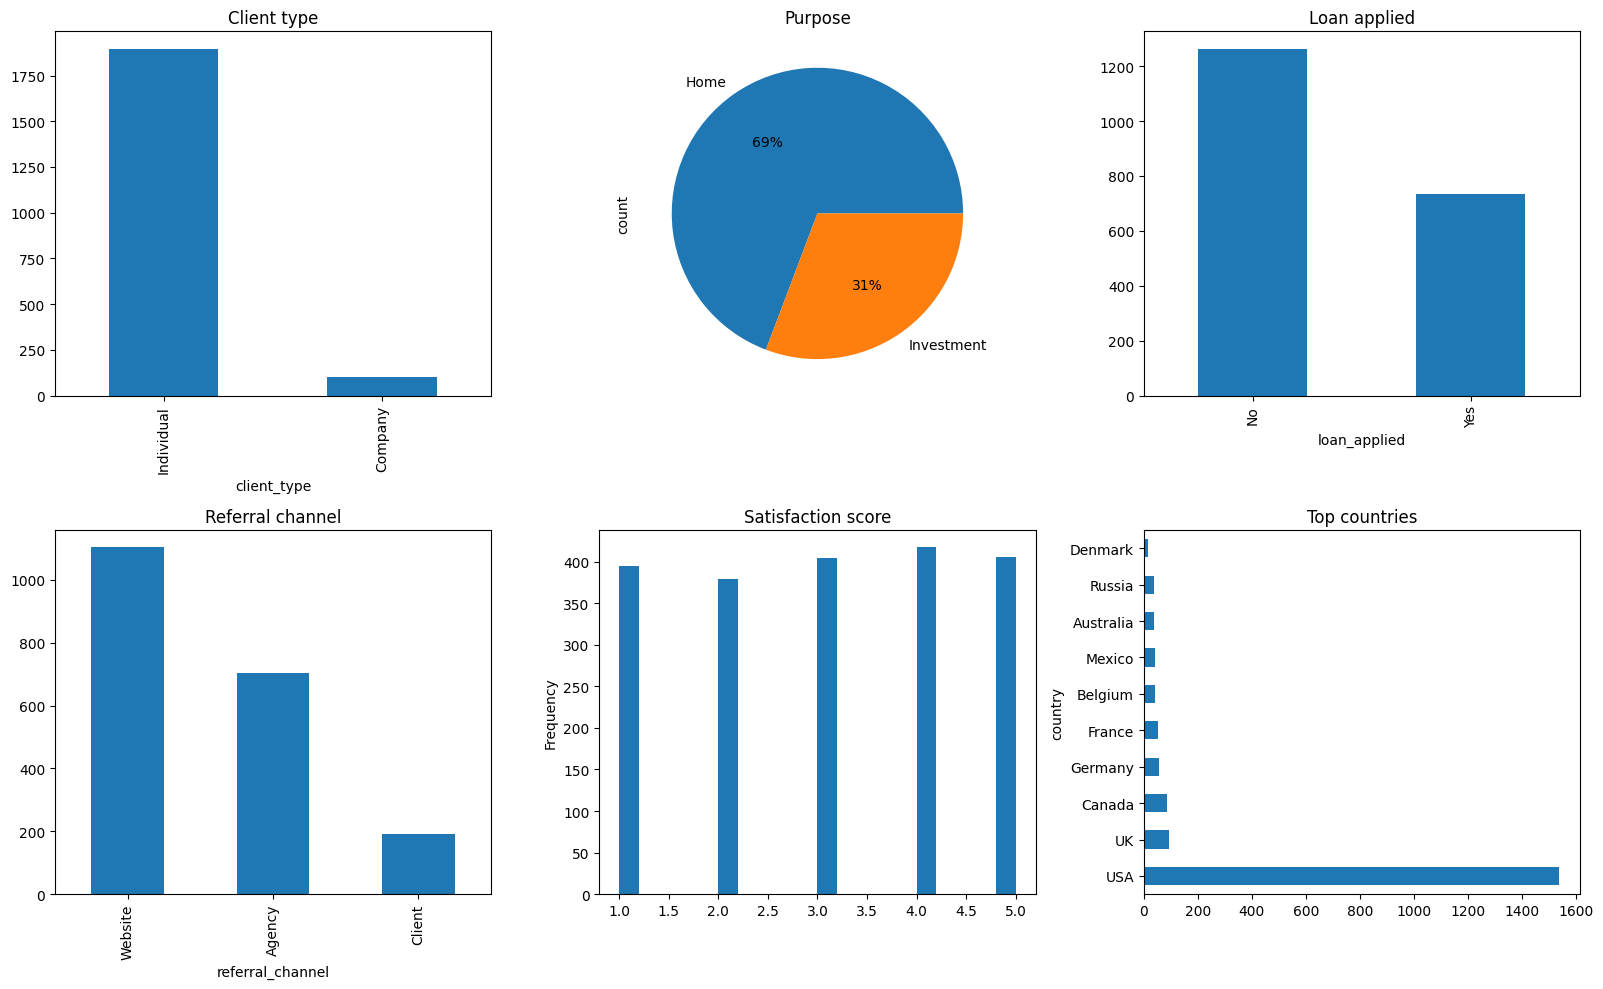

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

clients['client_type'].value_counts().plot(kind='bar', ax=axes[0,0], title='Client type')
clients['acquisition_purpose'].value_counts().plot(kind='pie', ax=axes[0,1], title='Purpose', autopct='%1.0f%%')
clients['loan_applied'].value_counts().plot(kind='bar', ax=axes[0,2], title='Loan applied')
clients['referral_channel'].value_counts().plot(kind='bar', ax=axes[1,0], title='Referral channel')
clients['satisfaction_score'].plot(kind='hist', ax=axes[1,1], title='Satisfaction score', bins=20)
clients['country'].value_counts().head(10).plot(kind='barh', ax=axes[1,2], title='Top countries')

plt.tight_layout()
plt.show()